# 03. Opinion Clustering (Opinosis) - 텍스트 전처리

## 데이터셋 소개
- **Opinosis Opinion/Review 데이터셋** (UCI): 아마존 킨들, 가민 내비게이션, 넷북, 혼다/도요타 차량, 호텔 등
  다양한 상품·서비스에 대한 **토픽별 리뷰 문장 모음**
- `data/topics/` 폴더에 51개의 `.txt.data` 파일이 있고, **파일 1개 = 토픽 1개**(예: `battery-life_amazon_kindle.txt.data`)
- 각 파일 안에는 해당 토픽에 대한 리뷰 문장이 여러 줄(line) 들어있음 -> 파일 전체를 이어 붙이면 "문서 1개"가 됨
- 목표: 51개 문서를 TF-IDF로 벡터화하여 K-Means/DBSCAN으로 군집화(비슷한 토픽끼리 묶기) — **이번 노트북은 그 전 단계인 텍스트 전처리 부분만 다룸**

## 전처리 파이프라인 (7단계)
1. **축약형 확장**: `isn't` -> `is not`, `didn't` -> `did not`, `it's` -> `it is` 처럼 축약형을 풀어씀
   - 구두점을 먼저 지워버리면 `isn't` -> `isnt`처럼 사전에 없는 이상한 토큰이 생기므로, 반드시 구두점 제거보다 먼저 수행
2. **소문자화**: `Great`와 `great`를 같은 단어로 취급하기 위해 전체 텍스트를 소문자로 변환
3. **구두점 제거**: 마침표, 쉼표, 느낌표 등 의미 없는 구두점을 제거
4. **토큰화**: 문장을 단어 단위(토큰)로 분리
5. **순수 숫자 토큰 제거**: `26`, `96`처럼 숫자로만 이루어진 토큰은 어휘 목록에서 제외 (연도·수치는 토픽 구분에 의미가 적음)
6. **불용어(stopword) 제거**: `the`, `is`, `and`, `not`처럼 거의 모든 문서에 등장해 토픽 구분에 기여하지 못하는 단어를 제거 (NLTK 영어 불용어 사전 사용)
   - 반드시 **표제어 추출보다 먼저** 수행: 불용어 사전은 원형(`was`, `does` 등) 기준으로 만들어져 있는데, 명사 기준 표제어 추출을 먼저 하면 `was` -> `wa`처럼 사전에 없는 형태로 바뀌어 버려서 불용어로 걸러지지 않고 그대로 남는 문제가 생김
7. **표제어(lemma) 추출**: 품사 태깅 없이 기본값(명사 기준)으로 표제어 추출하여 원형화 (토픽을 가르는 단어는 대부분 명사이므로 이 정도로 충분)


In [1]:
import os
import re
import glob
import string

import pandas as pd

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# 최초 실행 환경에서 필요한 nltk 데이터가 없다면 자동으로 내려받음 (이미 있으면 스킵됨)
for pkg, path in [("punkt", "tokenizers/punkt"), ("punkt_tab", "tokenizers/punkt_tab"),
                   ("wordnet", "corpora/wordnet"), ("omw-1.4", "corpora/omw-1.4"),
                   ("stopwords", "corpora/stopwords")]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(pkg, quiet=True)


## 1. 데이터 로드
`data/topics/*.txt.data` 51개 파일을 읽어서, 파일 하나당 한 행(row)인 DataFrame으로 구성한다.
파일명 자체에 토픽 정보(`속성_상품명`)가 들어있으므로 함께 컬럼으로 분리해둔다.

In [2]:
topic_files = sorted(glob.glob("../data/topics/*.txt.data"))
print("문서(파일) 개수:", len(topic_files))
topic_files[:5]


문서(파일) 개수: 51


['../data/topics\\accuracy_garmin_nuvi_255W_gps.txt.data',
 '../data/topics\\bathroom_bestwestern_hotel_sfo.txt.data',
 '../data/topics\\battery-life_amazon_kindle.txt.data',
 '../data/topics\\battery-life_ipod_nano_8gb.txt.data',
 '../data/topics\\battery-life_netbook_1005ha.txt.data']

In [3]:
filenames = []
opinion_texts = []

for file_path in topic_files:
    filename = os.path.basename(file_path)
    # 확장자(.txt.data) 제거 -> 순수 토픽명만 남김
    filename = filename.replace(".txt.data", "")

    with open(file_path, "r", encoding="latin1") as f:
        # 파일 안의 여러 줄(문장)을 공백으로 이어붙여 문서 1개로 합침
        text = " ".join(f.readlines())

    filenames.append(filename)
    opinion_texts.append(text)

document_df = pd.DataFrame({"filename": filenames, "opinion_text": opinion_texts})
print("문서 개수:", len(document_df))
document_df.head()


문서 개수: 51


,filename,opinion_text
0,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate .\n but for the ..."
1,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and ve..."
2,battery-life_amazon_kindle,After I plugged it in to my USB hub on my com...
3,battery-life_ipod_nano_8gb,short battery life I moved up from an 8gb .\...
4,battery-life_netbook_1005ha,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh ..."


In [4]:
# 파일명(예: battery-life_amazon_kindle)에서 속성(attribute)과 상품명(product)을 분리
# -> 첫 '_' 이전은 속성, 이후는 상품명으로 간주
# 주의: "gas_mileage_toyota_camry_2007"처럼 속성 이름 자체에 '_'가 들어간 경우
#      (gas_mileage)는 이 규칙으로 정확히 안 갈라짐 (attribute="gas", product="mileage_toyota_camry_2007"로 잘못 분리됨)
#      -> attribute/product는 참고용 컬럼이라 이번엔 그대로 두고, 평가용 pseudo-label(category)은 아래에서 별도 규칙으로 만듦
document_df["attribute"] = document_df["filename"].apply(lambda x: x.split("_", 1)[0])
document_df["product"] = document_df["filename"].apply(lambda x: x.split("_", 1)[1] if "_" in x else "")

document_df[["filename", "attribute", "product"]].head(10)


,filename,attribute,product
0,accuracy_garmin_nuvi_255W_gps,accuracy,garmin_nuvi_255W_gps
1,bathroom_bestwestern_hotel_sfo,bathroom,bestwestern_hotel_sfo
2,battery-life_amazon_kindle,battery-life,amazon_kindle
3,battery-life_ipod_nano_8gb,battery-life,ipod_nano_8gb
4,battery-life_netbook_1005ha,battery-life,netbook_1005ha
5,buttons_amazon_kindle,buttons,amazon_kindle
6,comfort_honda_accord_2008,comfort,honda_accord_2008
7,comfort_toyota_camry_2007,comfort,toyota_camry_2007
8,directions_garmin_nuvi_255W_gps,directions,garmin_nuvi_255W_gps
9,display_garmin_nuvi_255W_gps,display,garmin_nuvi_255W_gps


### 1-1. 평가용 pseudo-label(`category`) 정의
군집화 결과를 검증(ARI/NMI)하기 위한 "정답에 가까운" 라벨을 파일명에서 직접 만든다.
**학습(TF-IDF/KMeans) 입력으로는 절대 쓰지 않고, 뒤쪽 최종 검증 단계에서만 사용한다.**

51개 문서는 크게 3개 대분류(전자기기 / 자동차 / 호텔)로 나뉘는 걸 파일명으로 확인할 수 있어서,
`attribute`/`product`의 split 버그와 무관하게 **파일명 전체에서 키워드로 직접** 분류한다.

In [5]:
def infer_category(filename: str) -> str:
    fn = filename.lower()
    if "hotel" in fn or "inn" in fn or "swissotel" in fn:
        return "hotel"
    elif "honda" in fn or "toyota" in fn or "accord" in fn or "camry" in fn:
        return "car"
    else:
        return "electronics"


document_df["category"] = document_df["filename"].apply(infer_category)
document_df["category"].value_counts()


category
electronics    25
hotel          16
car            10
Name: count, dtype: int64

In [6]:
print(document_df["opinion_text"].iloc[0][:500])


, and is very, very accurate .
  but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .
  This function is not accurate if you don't leave it in battery mode say, when you stop at the Cracker Barrell for lunch and to play one of those trangle games with the tees .
  It provides immediate alternatives if the route from the online map program was inaccurate or blocked by an obstacle .
  I've used other GPS units, as well as GPS built into 


## 2. 단계별 전처리 함수 정의

각 단계를 먼저 개별 함수로 만들어 샘플 문장으로 동작을 확인한 뒤, 마지막에 하나의 파이프라인 함수로 합친다.

### 2-1. 축약형 확장 (Contraction Expansion)
`isn't`, `didn't`, `it's` 처럼 자주 쓰이는 축약형을 원래 형태로 풀어주는 매핑 테이블을 만들고,
정규식으로 원문에서 찾아 치환한다. **구두점 제거보다 반드시 먼저** 실행해야
`isn't` -> `isnt` 같은 깨진 토큰이 생기지 않는다.

In [7]:
CONTRACTION_MAP = {
    "isn't": "is not", "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "won't": "will not", "wouldn't": "would not",
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "couldn't": "could not",
    "shouldn't": "should not", "mightn't": "might not", "mustn't": "must not",
    "it's": "it is", "that's": "that is", "there's": "there is", "here's": "here is",
    "what's": "what is", "who's": "who is", "let's": "let us",
    "i'm": "i am", "you're": "you are", "we're": "we are", "they're": "they are",
    "i've": "i have", "you've": "you have", "we've": "we have", "they've": "they have",
    "i'll": "i will", "you'll": "you will", "we'll": "we will", "they'll": "they will",
    "i'd": "i would", "you'd": "you would", "we'd": "we would", "they'd": "they would",
    "he's": "he is", "she's": "she is",
    "he'll": "he will", "she'll": "she will",
    "he'd": "he would", "she'd": "she would",
    "would've": "would have", "could've": "could have", "should've": "should have",
    "might've": "might have", "must've": "must have",
}

# 매핑 테이블의 key들을 하나의 정규식 패턴으로 결합 (대소문자 무시)
_CONTRACTION_PATTERN = re.compile(
    r"\b({})\b".format("|".join(re.escape(k) for k in CONTRACTION_MAP.keys())),
    flags=re.IGNORECASE,
)


def expand_contractions(text: str) -> str:
    def _replace(match):
        return CONTRACTION_MAP[match.group(0).lower()]
    return _CONTRACTION_PATTERN.sub(_replace, text)


# 동작 확인
sample = "I bought this and isn't it great? It's fast, but the battery didn't last long."
print("원문 :", sample)
print("확장 :", expand_contractions(sample))


원문 : I bought this and isn't it great? It's fast, but the battery didn't last long.
확장 : I bought this and is not it great? it is fast, but the battery did not last long.


### 2-2. 소문자화 + 구두점 제거
`Great`와 `great`를 같은 단어로 취급하기 위해 소문자화하고, `string.punctuation`에 정의된
구두점 문자를 전부 제거한다.

In [8]:
# string.punctuation에 있는 모든 구두점 문자 -> None(삭제) 매핑 테이블
REMOVE_PUNCT_MAP = dict((ord(punct), None) for punct in string.punctuation)


def to_lower_and_remove_punct(text: str) -> str:
    return text.lower().translate(REMOVE_PUNCT_MAP)


# 동작 확인 (위에서 축약형을 먼저 풀어준 문장을 이어서 처리)
expanded = expand_contractions(sample)
cleaned = to_lower_and_remove_punct(expanded)
print("소문자화 + 구두점 제거 전:", expanded)
print("소문자화 + 구두점 제거 후:", cleaned)


소문자화 + 구두점 제거 전: I bought this and is not it great? it is fast, but the battery did not last long.
소문자화 + 구두점 제거 후: i bought this and is not it great it is fast but the battery did not last long


### 2-3. 토큰화
정제된 문장을 단어 단위로 쪼갠다.

In [9]:
tokens = word_tokenize(cleaned)
print(tokens)


['i', 'bought', 'this', 'and', 'is', 'not', 'it', 'great', 'it', 'is', 'fast', 'but', 'the', 'battery', 'did', 'not', 'last', 'long']


### 2-4. 순수 숫자 토큰 제거
`26`, `96`처럼 숫자로만 이루어진 토큰은 주제를 구분하는 데 의미가 없으므로 제외한다.
(`1005ha`처럼 문자가 섞인 토큰은 `isdigit()`이 False이므로 그대로 유지됨)

In [10]:
sample_with_number = "in 2008 the battery lasted about 26 to 96 hours on the 1005ha model"
number_tokens = word_tokenize(sample_with_number)
print("숫자 제거 전:", number_tokens)

filtered_tokens = [t for t in number_tokens if not t.isdigit()]
print("숫자 제거 후:", filtered_tokens)


숫자 제거 전: ['in', '2008', 'the', 'battery', 'lasted', 'about', '26', 'to', '96', 'hours', 'on', 'the', '1005ha', 'model']
숫자 제거 후: ['in', 'the', 'battery', 'lasted', 'about', 'to', 'hours', 'on', 'the', '1005ha', 'model']


### 2-5. 불용어(Stopword) 제거
`the`, `is`, `and`, `not`처럼 거의 모든 문서에 등장해서 토픽을 구분하는 데 도움이 안 되는
단어(불용어)를 NLTK 영어 불용어 사전으로 제거한다. **표제어 추출보다 먼저** 수행해야
불용어 사전의 원형(`was`, `does` 등)과 정확히 매칭된다.

In [11]:
STOPWORDS = set(stopwords.words("english"))
print("불용어 개수:", len(STOPWORDS))
print(sorted(STOPWORDS)[:15])


불용어 개수: 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]


In [12]:
def remove_stopwords(tokens: list) -> list:
    return [t for t in tokens if t not in STOPWORDS]


# 동작 확인 (2-4에서 만든 filtered_tokens에 이어서 적용)
print("불용어 제거 전:", filtered_tokens)
print("불용어 제거 후:", remove_stopwords(filtered_tokens))


불용어 제거 전: ['in', 'the', 'battery', 'lasted', 'about', 'to', 'hours', 'on', 'the', '1005ha', 'model']
불용어 제거 후: ['battery', 'lasted', 'hours', '1005ha', 'model']


In [13]:
# 왜 표제어 추출보다 먼저 해야 하는지 확인
# -> 명사 기준 표제어 추출기는 "was"를 복수형 명사로 착각해 "wa"로 바꿔버림
# -> 이 상태로 불용어 제거를 하면 "wa"는 불용어 사전에 없어서 걸러지지 않고 그대로 남음
lemmatizer = WordNetLemmatizer()

print("올바른 순서 (불용어 제거 -> 표제어 추출):", "was" in STOPWORDS)
print("잘못된 순서로 표제어 추출부터 하면      :", lemmatizer.lemmatize("was"), "->", lemmatizer.lemmatize("was") in STOPWORDS)


올바른 순서 (불용어 제거 -> 표제어 추출): True


잘못된 순서로 표제어 추출부터 하면      : wa -> False


### 2-6. 표제어(lemma) 추출
품사 태깅 없이 `WordNetLemmatizer`의 기본값(명사 기준, `pos="n"`)으로 표제어를 추출한다.
토픽(주제)을 가르는 단어는 대부분 명사이기 때문에 이 정도로도 충분하다.

In [14]:
sample_nouns = ["batteries", "screens", "buttons", "reviews", "companies"]
lemmatized = [lemmatizer.lemmatize(t) for t in sample_nouns]

for before, after in zip(sample_nouns, lemmatized):
    print(f"{before:>10} -> {after}")


 batteries -> battery
   screens -> screen
   buttons -> button
   reviews -> review
 companies -> company


## 3. 전체 파이프라인 통합

위에서 확인한 7단계를 순서대로 실행하는 하나의 함수로 합친다.
이 함수는 이후 `TfidfVectorizer(tokenizer=...)`에 그대로 전달해 벡터화 단계에서 재사용할 수 있다.

In [15]:
def preprocess_text(text: str) -> list:
    # 1. 축약형 확장 (구두점 제거보다 반드시 먼저)
    text = expand_contractions(text)
    # 2. 소문자화
    text = text.lower()
    # 3. 구두점 제거
    text = text.translate(REMOVE_PUNCT_MAP)
    # 4. 토큰화
    tokens = word_tokenize(text)
    # 5. 순수 숫자 토큰 제거
    tokens = [t for t in tokens if not t.isdigit()]
    # 6. 불용어 제거 (표제어 추출보다 반드시 먼저, was->wa 같은 오원형화로 인한 누락 방지)
    tokens = remove_stopwords(tokens)
    # 7. 표제어 추출 (명사 기준)
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens


# 샘플 문서로 전체 파이프라인 동작 확인
demo_text = "I didn't expect the battery wouldn't last, but in 2011 it's improved a lot over 2 years."
print("원문   :", demo_text)
print("전처리 :", preprocess_text(demo_text))


원문   : I didn't expect the battery wouldn't last, but in 2011 it's improved a lot over 2 years.
전처리 : ['expect', 'battery', 'would', 'last', 'improved', 'lot', 'year']


In [16]:
# 실제 topics 문서 하나(battery-life_amazon_kindle)에 적용해서 비교
row = document_df[document_df["filename"] == "battery-life_amazon_kindle"].iloc[0]

print("=== 원문 (앞부분) ===")
print(row["opinion_text"][:300])
print()
print("=== 전처리 결과 (토큰, 앞부분) ===")
print(preprocess_text(row["opinion_text"])[:30])


=== 원문 (앞부분) ===
 After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever !
  After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get ther

=== 전처리 결과 (토큰, 앞부분) ===
['plugged', 'usb', 'hub', 'computer', 'charge', 'battery', 'charging', 'cord', 'design', 'clever', 'paged', 'tru', 'page', 'book', 'one', 'page', 'time', 'get', 'chapter', 'chapter', 'see', 'excited', 'low', 'battery', 'time', 'took', 'get', 'user', 'replaceable', 'battery']


## 4. 전체 문서(51개)에 전처리 적용
`document_df`의 모든 `opinion_text`에 파이프라인을 적용해 토큰 리스트 컬럼을 만들어둔다.
(다음 단계인 TF-IDF 벡터화 + K-Means/DBSCAN 군집화는 별도 노트북에서 이어서 진행)

In [17]:
document_df["tokens"] = document_df["opinion_text"].apply(preprocess_text)
document_df["token_count"] = document_df["tokens"].apply(len)

document_df[["filename", "attribute", "product", "token_count"]].head(10)


,filename,attribute,product,token_count
0,accuracy_garmin_nuvi_255W_gps,accuracy,garmin_nuvi_255W_gps,547
1,bathroom_bestwestern_hotel_sfo,bathroom,bestwestern_hotel_sfo,739
2,battery-life_amazon_kindle,battery-life,amazon_kindle,892
3,battery-life_ipod_nano_8gb,battery-life,ipod_nano_8gb,619
4,battery-life_netbook_1005ha,battery-life,netbook_1005ha,3262
5,buttons_amazon_kindle,buttons,amazon_kindle,1653
6,comfort_honda_accord_2008,comfort,honda_accord_2008,1354
7,comfort_toyota_camry_2007,comfort,toyota_camry_2007,924
8,directions_garmin_nuvi_255W_gps,directions,garmin_nuvi_255W_gps,1025
9,display_garmin_nuvi_255W_gps,display,garmin_nuvi_255W_gps,511


In [18]:
print("문서별 토큰 개수 통계")
document_df["token_count"].describe()


문서별 토큰 개수 통계


count      51.000000
mean     1276.137255
std       975.203753
min       416.000000
25%       706.500000
50%       934.000000
75%      1358.000000
max      5973.000000
Name: token_count, dtype: float64

In [19]:
document_df.head()


,filename,opinion_text,attribute,product,category,tokens,token_count
0,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate .\n but for the ...",accuracy,garmin_nuvi_255W_gps,electronics,"[accurate, part, find, garmin, software, provi...",547
1,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and ve...",bathroom,bestwestern_hotel_sfo,hotel,"[room, overly, big, clean, comfortable, bed, g...",739
2,battery-life_amazon_kindle,After I plugged it in to my USB hub on my com...,battery-life,amazon_kindle,electronics,"[plugged, usb, hub, computer, charge, battery,...",892
3,battery-life_ipod_nano_8gb,short battery life I moved up from an 8gb .\...,battery-life,ipod_nano_8gb,electronics,"[short, battery, life, moved, 8gb, love, ipod,...",619
4,battery-life_netbook_1005ha,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh ...",battery-life,netbook_1005ha,electronics,"[6ghz, 533fsb, cpu, glossy, display, cell, 23w...",3262


### 4-1. 전처리 결과 시각화
전처리가 끝난 뒤의 토큰 분포와 실제로 어떤 단어가 자주 등장하는지 눈으로 확인한다.

In [20]:
import matplotlib.pyplot as plt
from collections import Counter

# Windows 환경에서 한글이 깨지지 않도록 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


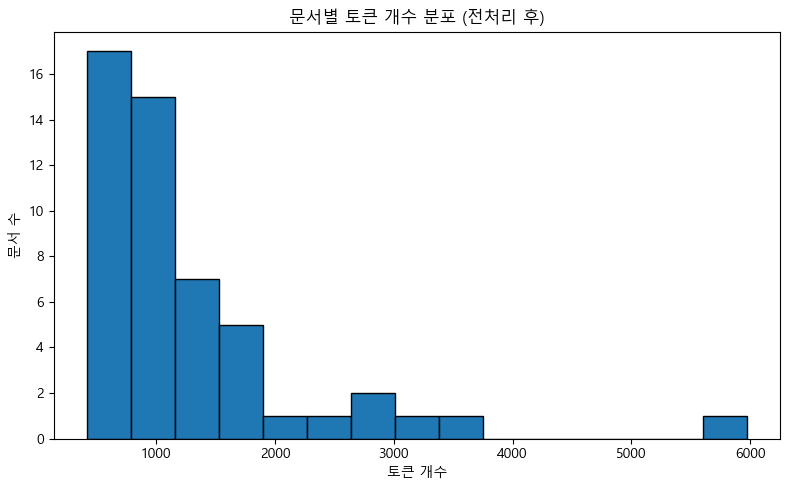

In [21]:
# 문서별 토큰 개수 분포 (전처리 후)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(document_df["token_count"], bins=15, edgecolor="black")
ax.set_title("문서별 토큰 개수 분포 (전처리 후)")
ax.set_xlabel("토큰 개수")
ax.set_ylabel("문서 수")
plt.tight_layout()
plt.show()


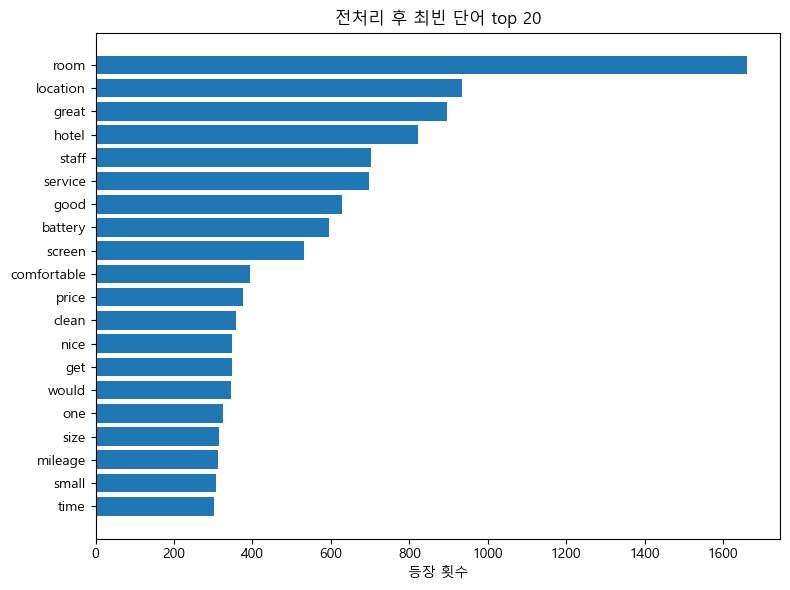

In [22]:
# 전체 문서에서 가장 많이 등장한 단어 top 20
# -> 불용어/구두점/숫자가 이미 다 제거된 상태라, 실제 주제를 대표하는 단어들이 상위에 나오는지 확인하는 용도
all_tokens = [token for tokens in document_df["tokens"] for token in tokens]
top_words = Counter(all_tokens).most_common(20)
words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(words[::-1], counts[::-1])
ax.set_title("전처리 후 최빈 단어 top 20")
ax.set_xlabel("등장 횟수")
plt.tight_layout()
plt.show()


## 5. TF-IDF 벡터화

`preprocess_text` 함수를 `TfidfVectorizer(tokenizer=...)`에 그대로 재사용한다.
그래서 `document_df["tokens"]`(미리 쪼개둔 결과)가 아니라 **원문 그대로인 `opinion_text`**를 입력으로 넣는다
— 벡터화기가 내부에서 문서마다 `preprocess_text(원문)`을 호출해 토큰을 얻기 때문.

- `ngram_range=(1, 2)`: "battery life", "gas mileage"처럼 단어 하나로는 안 드러나는 의미 있는 2단어 조합도 반영
- `min_df=0.05`: 문서의 5% 미만(51개 중 3개 미만)에서만 등장하는 지나치게 희귀한 토큰 제외
- `max_df=0.85`: 문서의 85% 이상에서 등장하는 지나치게 흔한 토큰 제외 (불용어를 이미 제거했지만, 도메인 특성상 여전히 흔한 단어를 한 번 더 필터링)
- `token_pattern=None`: 커스텀 `tokenizer`를 쓸 때 sklearn 기본 정규식 토큰 패턴이 무시된다는 경고를 없애기 위해 명시

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    tokenizer=preprocess_text,
    token_pattern=None,
    ngram_range=(1, 2),
    min_df=0.05,
    max_df=0.85,
)

feature_vect = tfidf_vectorizer.fit_transform(document_df["opinion_text"])
print("TF-IDF 행렬 shape:", feature_vect.shape)
# (51, 어휘 수) -> 문서 51개 x 선택된 (유니그램+바이그램) 어휘 수


TF-IDF 행렬 shape: (51, 4498)


### 5-1. `feature_vect`가 희소 행렬(sparse matrix)인지 확인
모델(특히 GMM, DBSCAN처럼 dense 입력이 필요하거나 고차원에서 취약한 모델)로 넘어가기 전에,
지금 만든 TF-IDF 행렬이 실제로 어떤 형태인지 먼저 찍어본다.

In [24]:
import scipy.sparse as sp

print("타입          :", type(feature_vect))
print("희소 행렬 여부 :", sp.issparse(feature_vect))
print("shape         :", feature_vect.shape)
print("0이 아닌 값 개수(nnz):", feature_vect.nnz)

n_rows, n_cols = feature_vect.shape
total_cells = n_rows * n_cols
density = feature_vect.nnz / total_cells
print(f"전체 셀 개수   : {total_cells:,}")
print(f"밀도(density) : {density:.4f}  ({density*100:.2f}%)")
print(f"희소도(sparsity): {1 - density:.4f}  ({(1-density)*100:.2f}%)")


타입          : <class 'scipy.sparse._csr.csr_matrix'>
희소 행렬 여부 : True
shape         : (51, 4498)
0이 아닌 값 개수(nnz): 28343
전체 셀 개수   : 229,398
밀도(density) : 0.1236  (12.36%)
희소도(sparsity): 0.8764  (87.64%)


**왜 희소 행렬인가?**

`feature_vect`는 "문서 x 어휘" 형태의 TF-IDF 행렬이다. 어휘 목록(컬럼)은 51개 문서 **전체**에서
한 번이라도 등장한 단어를 모아 만든 것인데, 개별 문서 하나는 그중 아주 일부 단어만 사용한다.
예를 들어 `battery-life_amazon_kindle` 문서는 `interior`, `transmission`, `hotel` 같은
자동차/호텔 관련 단어를 전혀 안 쓰니 그 칸은 전부 0이 된다. 그래서 위에서 확인했듯
전체 셀의 87% 이상이 0인 희소 행렬이 되는 것이고, 이는 TF-IDF/BoW 방식 자체의 자연스러운 특징이다.

**지금 찍은 shape `(51, 4498)`가 정확히 뜻하는 것**

- **51** = 문서(row) 개수. 이후 모든 클러스터링 모델에게 "51개의 데이터 포인트"로 취급됨
- **4498** = 어휘(column) 개수, 즉 문서 하나를 표현하는 **피처(차원) 개수**. 문서 간 거리(KMeans가 쓰는 유클리드 거리 등)는
  이 4498차원 공간에서 계산됨
- 이 shape는 곧바로 다음처럼 코드에 그대로 이어진다:
  - `kmeans.cluster_centers_`의 shape가 `(3, 4498)`이 되고, `get_cluster_top_features`에서
    이 4498개 컬럼을 어휘(`feature_names`)와 매칭해 클러스터별 핵심 키워드를 뽑아낸 것
  - 앞으로 붙일 **GMM/DBSCAN 등은 이 4498차원이 너무 높고 희소해서 그대로 쓰기 부적합** →
    바로 아래에서 이 `(51, 4498)` 희소 행렬을 훨씬 작은 dense 차원으로 압축(LSA)해서
    이후 모델들이 공통으로 재사용할 입력을 만든다

### 5-2. 차원 축소: PCA가 아니라 LSA(TruncatedSVD)를 쓰는 이유

바로 위에서 `feature_vect`가 **scipy 희소 행렬**이라는 걸 확인했다. 이 사실 하나만으로 PCA는 제외된다.

1. **`sklearn.decomposition.PCA`는 희소 입력 자체를 못 받음** — 넣으면 `TypeError`가 남. 억지로 쓰려면
   `.toarray()`로 강제 dense 변환을 해야 하는데, 이는 우회일 뿐 정상적인 사용법이 아님
2. **PCA의 평균 중심화(mean-centering)가 TF-IDF와 안 맞음** — TF-IDF의 0은 "이 단어가 이 문서에 없다"는
   의미 있는 정보인데, PCA가 평균을 빼버리면 이 0들이 전부 자잘한 음수로 바뀌어서 "단어 없음"이라는
   의미가 사라짐
3. **TruncatedSVD(LSA)는 중심화 없이 원본 행렬에 바로 SVD를 적용** — 희소 행렬을 그대로 받을 수 있고,
   "단어-문서 행렬에 SVD를 적용한다"는 것 자체가 Latent Semantic Analysis(LSA)의 정의라서
   텍스트/TF-IDF 차원 축소에 표준으로 쓰이는 기법

참고로 이 프로젝트의 `02_classification_credit_card`에서 쓴 PCA(V1~V28)는 **이미 평균 0에 가까운 dense
연속형 신호**였기 때문에 PCA가 잘 맞았던 것이고, 지금 TF-IDF는 성격이 반대(희소·비음수·카운트 기반)라
같은 "차원 축소"라도 도구를 다르게 선택해야 한다.

In [25]:
from sklearn.decomposition import TruncatedSVD

# 몇 개 컴포넌트면 원본 정보를 얼마나 보존하는지 먼저 확인
candidate_ks = [5, 10, 15, 20, 25, 30, 40]
cum_explained_var = []
for k in candidate_ks:
    svd_probe = TruncatedSVD(n_components=k, random_state=42)
    svd_probe.fit(feature_vect)
    ratio = svd_probe.explained_variance_ratio_.sum()
    cum_explained_var.append(ratio)
    print(f"n_components={k:3d}  누적 설명된 분산 비율={ratio:.4f}")


n_components=  5  누적 설명된 분산 비율=0.2692
n_components= 10  누적 설명된 분산 비율=0.4526
n_components= 15  누적 설명된 분산 비율=0.5997
n_components= 20  누적 설명된 분산 비율=0.7182
n_components= 25  누적 설명된 분산 비율=0.8168
n_components= 30  누적 설명된 분산 비율=0.8929
n_components= 40  누적 설명된 분산 비율=0.9779


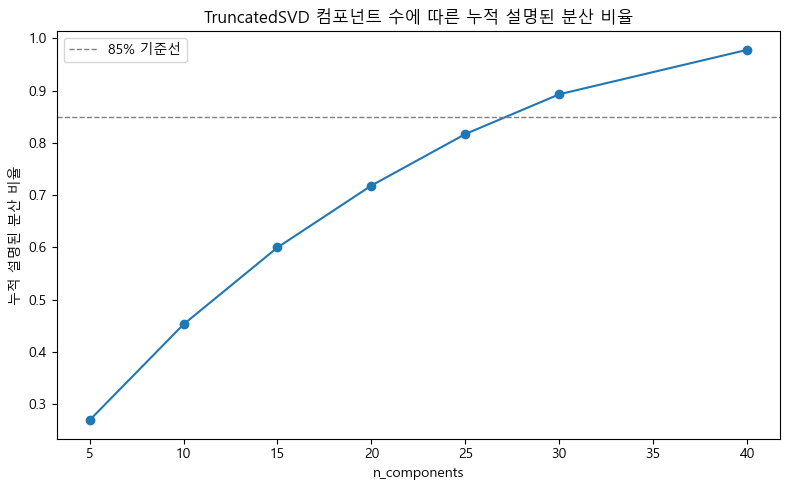

In [26]:
# 위 결과를 스크리 플롯(scree plot)으로 시각화 -> 몇 개 컴포넌트부터 "수확 체감"이 시작되는지 한눈에 확인
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(candidate_ks, cum_explained_var, marker="o")
ax.axhline(0.85, color="gray", linestyle="--", linewidth=1, label="85% 기준선")
ax.set_title("TruncatedSVD 컴포넌트 수에 따른 누적 설명된 분산 비율")
ax.set_xlabel("n_components")
ax.set_ylabel("누적 설명된 분산 비율")
ax.legend()
plt.tight_layout()
plt.show()


`n_components=30` 근처에서 누적 설명된 분산이 약 89%로 충분히 높으면서, 문서 수(51개)에 비해
과도하게 크지 않은 값이라 이걸 채택한다. (`TruncatedSVD`는 `n_components < min(n_samples, n_features)`
제약이 있어서 51보다는 반드시 작아야 함)

In [27]:
svd = TruncatedSVD(n_components=30, random_state=42)
lsa_features_raw = svd.fit_transform(feature_vect)

print("LSA 축소 전 (희소, sparse) shape:", feature_vect.shape)
print("LSA 축소 후 (dense, ndarray) shape:", lsa_features_raw.shape)
print("타입:", type(lsa_features_raw))
print("누적 설명된 분산 비율:", svd.explained_variance_ratio_.sum().round(4))


LSA 축소 전 (희소, sparse) shape: (51, 4498)
LSA 축소 후 (dense, ndarray) shape: (51, 30)
타입: <class 'numpy.ndarray'>
누적 설명된 분산 비율: 0.8929


### 5-3. SVD 축소 후 L2 정규화가 필요한 이유

`TruncatedSVD`는 원본 TF-IDF와 달리 **결과 벡터의 길이(norm)를 1로 맞춰주지 않는다.**
(원래 `TfidfVectorizer`는 기본적으로 각 문서 벡터를 L2 정규화해서 반환하지만, SVD로 축소하고 나면
그 성질이 깨지고 컴포넌트마다 크기가 들쭉날쭉해진다.) 그 상태로 KMeans 같은 유클리드 거리 기반
모델에 넣으면 특정 컴포넌트(분산이 큰 축)가 거리 계산을 과도하게 지배해버릴 수 있다.

그래서 SVD 축소 뒤에 `Normalizer`(L2)를 한 번 더 적용하는 게 텍스트 클러스터링의 표준 관행이다.
실제로 효과가 있는지 KMeans(LSA)의 ARI로 직접 비교해본다.

In [28]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import Normalizer
from sklearn.metrics import adjusted_rand_score

# 정규화 전
km_before = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(lsa_features_raw)
ari_before = adjusted_rand_score(document_df["category"], km_before)

# 정규화 후
lsa_features_normalized = Normalizer(copy=False).fit_transform(lsa_features_raw)
km_after = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(lsa_features_normalized)
ari_after = adjusted_rand_score(document_df["category"], km_after)

print(f"L2 정규화 전 KMeans(LSA) ARI: {ari_before:.4f}")
print(f"L2 정규화 후 KMeans(LSA) ARI: {ari_after:.4f}")


L2 정규화 전 KMeans(LSA) ARI: 0.3666
L2 정규화 후 KMeans(LSA) ARI: 0.8869


C:\Users\mega\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mega\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


정규화 후 ARI가 뚜렷하게 올라간 걸 확인했다 (수치는 위 실행 결과 참고). 그래서 앞으로 모든
LSA 기반 모델은 정규화까지 마친 `feature_vect_lsa`를 입력으로 쓴다.

In [29]:
feature_vect_lsa = lsa_features_normalized
print("최종 feature_vect_lsa shape:", feature_vect_lsa.shape)


최종 feature_vect_lsa shape: (51, 30)


이제 `feature_vect`(원본 희소 4498차원, KMeans-raw가 사용)와
`feature_vect_lsa`(dense 30차원 + L2 정규화, 이후 KMeans-LSA/Agglomerative/HDBSCAN/GMM이 공통으로 사용)
두 가지 입력을 모두 갖췄다.

## 6. K-Means 군집화 (n_clusters=3)

`n_clusters=3`으로 고정해서 학습한다. (이번 단계는 k 자체를 실루엣으로 탐색하는 4단계가 아니라,
정해진 k=3에 대해 KMeans를 학습하고 결과를 확인하는 단계)

In [30]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, max_iter=10000, random_state=42, n_init=10)
kmeans_cluster_label = kmeans.fit_predict(feature_vect)

# 컬럼명에 모델 이름을 붙여둔다 -> 이후 GMM/DBSCAN 등 다른 모델 결과도
# gmm_cluster_label, dbscan_cluster_label 처럼 같은 document_df에 나란히 추가해서 한 번에 비교하기 위함
document_df["kmeans_cluster_label"] = kmeans_cluster_label
document_df["kmeans_cluster_label"].value_counts().sort_index()


kmeans_cluster_label
0    25
1    10
2    16
Name: count, dtype: int64

### 클러스터별 문서(파일명) 확인
각 클러스터에 어떤 토픽 파일들이 묶였는지 확인한다.

In [31]:
for cluster_num in sorted(document_df["kmeans_cluster_label"].unique()):
    print(f"=== cluster {cluster_num} ===")
    filenames_in_cluster = document_df[document_df["kmeans_cluster_label"] == cluster_num]["filename"].tolist()
    for fn in filenames_in_cluster:
        print(" -", fn)
    print()


=== cluster 0 ===
 - accuracy_garmin_nuvi_255W_gps
 - battery-life_amazon_kindle
 - battery-life_ipod_nano_8gb
 - battery-life_netbook_1005ha
 - buttons_amazon_kindle
 - directions_garmin_nuvi_255W_gps
 - display_garmin_nuvi_255W_gps
 - eyesight-issues_amazon_kindle
 - features_windows7
 - fonts_amazon_kindle
 - keyboard_netbook_1005ha
 - navigation_amazon_kindle
 - performance_netbook_1005ha
 - price_amazon_kindle
 - satellite_garmin_nuvi_255W_gps
 - screen_garmin_nuvi_255W_gps
 - screen_ipod_nano_8gb
 - screen_netbook_1005ha
 - size_asus_netbook_1005ha
 - sound_ipod_nano_8gb
 - speed_garmin_nuvi_255W_gps
 - speed_windows7
 - updates_garmin_nuvi_255W_gps
 - video_ipod_nano_8gb
 - voice_garmin_nuvi_255W_gps

=== cluster 1 ===
 - comfort_honda_accord_2008
 - comfort_toyota_camry_2007
 - gas_mileage_toyota_camry_2007
 - interior_honda_accord_2008
 - interior_toyota_camry_2007
 - mileage_honda_accord_2008
 - performance_honda_accord_2008
 - quality_toyota_camry_2007
 - seats_honda_accord_

### 클러스터별 핵심 키워드 확인
각 클러스터 중심(centroid)에서 TF-IDF 가중치가 가장 높은 상위 단어를 뽑아,
그 클러스터가 실제로 어떤 주제로 묶였는지 해석해본다.

In [32]:
def get_cluster_top_features(cluster_model, feature_names, top_n=10):
    # cluster_centers_: (클러스터 수, 어휘 수) 형태의 중심 좌표
    # 각 행(클러스터)을 값이 큰 순서로 정렬한 피처 인덱스를 구함
    centroid_feature_order = cluster_model.cluster_centers_.argsort()[:, ::-1]

    cluster_top_features = {}
    for cluster_num in range(cluster_model.n_clusters):
        top_feature_idx = centroid_feature_order[cluster_num, :top_n]
        cluster_top_features[cluster_num] = [feature_names[idx] for idx in top_feature_idx]
    return cluster_top_features


feature_names = tfidf_vectorizer.get_feature_names_out()
cluster_top_features = get_cluster_top_features(kmeans, feature_names, top_n=10)

for cluster_num, top_features in cluster_top_features.items():
    print(f"cluster {cluster_num} 핵심 키워드:", top_features)


cluster 0 핵심 키워드: ['screen', 'battery', 'keyboard', 'battery life', 'life', 'kindle', 'video', 'direction', 'feature', 'voice']
cluster 1 핵심 키워드: ['interior', 'seat', 'mileage', 'comfortable', 'gas', 'gas mileage', 'transmission', 'car', 'performance', 'quality']
cluster 2 핵심 키워드: ['room', 'hotel', 'service', 'staff', 'food', 'location', 'bathroom', 'clean', 'price', 'parking']


## 7. KMeans 결과 최종 검증 (Silhouette + ARI/NMI)

다른 모델(GMM, DBSCAN 등)로 넘어가기 전에, 지금까지 만든 KMeans(k=3) 결과가 실제로
잘 나온 게 맞는지 앞서 정한 두 가지 지표로 확인한다.

- **Silhouette**: 라벨(정답) 없이, 군집 결과(`kmeans_cluster_label`)와 거리 정보만으로 "구조적으로 잘 갈라졌나"를 봄
- **ARI / NMI**: 파일명 기반 pseudo-label(`category`)과 비교해서 "우리가 아는 도메인 구조와 실제로 일치하나"를 봄

두 지표가 답하는 질문이 다르므로 같이 확인한다.

In [33]:
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

silhouette = silhouette_score(feature_vect, kmeans_cluster_label)
ari = adjusted_rand_score(document_df["category"], kmeans_cluster_label)
nmi = normalized_mutual_info_score(document_df["category"], kmeans_cluster_label)

print(f"Silhouette Score : {silhouette:.4f}")
print(f"ARI              : {ari:.4f}")
print(f"NMI              : {nmi:.4f}")


Silhouette Score : 0.0860
ARI              : 1.0000
NMI              : 1.0000


### 두 지표를 같이 보면 알 수 있는 것
`category`(전자기기/자동차/호텔) vs `kmeans_cluster_label`(KMeans 결과)를 표로 직접 대조해본다.

In [34]:
pd.crosstab(document_df["category"], document_df["kmeans_cluster_label"])


kmeans_cluster_label,0,1,2
category,,,
car,0,10,0
electronics,25,0,0
hotel,0,0,16


**해석**

- **ARI = 1.0, NMI = 1.0**: 위 교차표에서 보이듯 KMeans(k=3)가 나눈 3개 클러스터가 `category`(전자기기/자동차/호텔)와
  **한 문서도 틀리지 않고 완전히 일치**한다. TF-IDF 벡터화 + 전처리 파이프라인이 이 데이터에서는 도메인 대분류를
  정확히 복원해낸 것으로 확인된다.
- **Silhouette = 0.086**: 절대값 자체는 낮은데, 이는 KMeans가 못해서가 아니라 TF-IDF처럼 희소·고차원(4천 차원 이상)
  벡터 공간에서는 원래 실루엣 값이 낮게 나오는 경향이 있기 때문이다(점들 사이 거리가 대체로 비슷해지는 현상).
  즉 "구조적 분리 정도(Silhouette)는 수치상 낮아 보여도, 실제 도메인 정답과는 완벽히 일치(ARI/NMI)"하는 경우이며,
  두 지표를 같이 봐야만 확인할 수 있는 결론이다. 이후 GMM/DBSCAN과 비교할 때도 Silhouette은 상대값으로,
  ARI/NMI는 정답 일치 여부로 각각 다르게 해석해야 한다.

(참고) `category` 라벨을 만드는 과정에서 처음엔 `"swissotel_chicago"`를 `"hotel"` 키워드 매칭 실패로
`electronics`로 잘못 분류했던 버그가 있었고, 그 상태로는 ARI/NMI가 1.0이 아니라 약 0.81 수준으로 나왔다.
`swissotel`을 호텔 키워드에 추가해 수정한 뒤 완전 일치로 확인됐다.

## 8. KMeans (LSA 축소본, n_clusters=3)

같은 KMeans, 같은 `n_clusters=3`이지만 입력만 `feature_vect`(원본 희소 4498차원) 대신
`feature_vect_lsa`(dense 30차원 + L2 정규화)로 바꿔서 돌린다. "차원을 압축해도 원본과 같은
결과가 나오는가"를 확인하기 위한 비교 실험이다.

In [35]:
kmeans_lsa = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_lsa_cluster_label = kmeans_lsa.fit_predict(feature_vect_lsa)

document_df["kmeans_lsa_cluster_label"] = kmeans_lsa_cluster_label

silhouette_kmeans_lsa = silhouette_score(feature_vect_lsa, kmeans_lsa_cluster_label)
ari_kmeans_lsa = adjusted_rand_score(document_df["category"], kmeans_lsa_cluster_label)
nmi_kmeans_lsa = normalized_mutual_info_score(document_df["category"], kmeans_lsa_cluster_label)

print(f"Silhouette : {silhouette_kmeans_lsa:.4f}")
print(f"ARI        : {ari_kmeans_lsa:.4f}")
print(f"NMI        : {nmi_kmeans_lsa:.4f}")


Silhouette : 0.1040
ARI        : 0.8869
NMI        : 0.8842


C:\Users\mega\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [36]:
pd.crosstab(document_df["category"], document_df["kmeans_lsa_cluster_label"])


kmeans_lsa_cluster_label,0,1,2
category,,,
car,10,0,0
electronics,2,0,23
hotel,0,16,0


KMeans-raw(ARI/NMI=1.0)보다 낮게 나온다. 즉 30차원으로 압축하는 과정에서 정보가 일부
손실되어, 이 데이터에서는 **원본 희소 TF-IDF를 그대로 쓰는 쪽이 KMeans에는 더 유리했다**는
뜻이다 — LSA가 항상 더 나은 결과를 보장하지는 않는다는 걸 보여주는 사례.

## 9. Agglomerative(계층적) Clustering (n_clusters=3)

`feature_vect_lsa`에 코사인 거리(`metric="cosine"`) + 평균 연결(`linkage="average"`)로 학습한다.
텍스트 클러스터링에서 자주 쓰이는 조합이다.

In [37]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3, linkage="average", metric="cosine")
agg_cluster_label = agg.fit_predict(feature_vect_lsa)

document_df["agg_cluster_label"] = agg_cluster_label

silhouette_agg = silhouette_score(feature_vect_lsa, agg_cluster_label)
ari_agg = adjusted_rand_score(document_df["category"], agg_cluster_label)
nmi_agg = normalized_mutual_info_score(document_df["category"], agg_cluster_label)

print(f"Silhouette : {silhouette_agg:.4f}")
print(f"ARI        : {ari_agg:.4f}")
print(f"NMI        : {nmi_agg:.4f}")


Silhouette : 0.1060
ARI        : 0.8768
NMI        : 0.8525


In [38]:
pd.crosstab(document_df["category"], document_df["agg_cluster_label"])


agg_cluster_label,0,1,2
category,,,
car,1,0,9
electronics,24,1,0
hotel,0,16,0


## 10. HDBSCAN

DBSCAN과 달리 `eps`를 직접 안 정해도 되고, `min_cluster_size`만 정해주면 된다.
다만 이 값에 따라 결과가 크게 달라지므로, 먼저 몇 가지 후보로 무슨 일이 일어나는지 확인한다.

In [39]:
from sklearn.cluster import HDBSCAN

for mcs in [2, 3, 4, 5]:
    labels = HDBSCAN(min_cluster_size=mcs).fit_predict(feature_vect_lsa)
    n_clusters_found = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    print(f"min_cluster_size={mcs}: 클러스터 {n_clusters_found}개, noise {n_noise}개")


min_cluster_size=2: 클러스터 18개, noise 8개
min_cluster_size=3: 클러스터 7개, noise 22개
min_cluster_size=4: 클러스터 2개, noise 16개
min_cluster_size=5: 클러스터 2개, noise 15개


`min_cluster_size=2~3`은 51개 문서를 7~18개의 잘게 쪼개진 클러스터로 나눠버려서
"의미 있는 군집화"로 보기 어렵다 (거의 대부분 2~4개짜리 초소형 클러스터).

그렇다고 `min_cluster_size=4, 5`가 기대한 3개로 수렴하는 것도 아니다 — 이 둘은 오히려 **2개**로
합쳐진다 (뒤에서 확인하겠지만, 전자기기와 자동차가 하나의 클러스터로 뭉쳐버린다). 즉 이 탐색
범위 안에는 "정확히 3개"를 만들어주는 min_cluster_size가 없다. 이것 자체가 솔직한 결과이므로
그대로 받아들이고, 너무 잘게 쪼개지는 2~3을 제외한 4~5 중에서는 noise를 제외한 Silhouette이
더 높은 `min_cluster_size=5`를 채택한다 (여기까지는 `category` 라벨을 보지 않고 고른 것).

In [40]:
hdbscan_model = HDBSCAN(min_cluster_size=5)
hdbscan_cluster_label = hdbscan_model.fit_predict(feature_vect_lsa)

document_df["hdbscan_cluster_label"] = hdbscan_cluster_label

n_noise = int((hdbscan_cluster_label == -1).sum())
print(f"noise로 분류된 문서 수: {n_noise} / {len(hdbscan_cluster_label)}")

# noise(-1)는 실루엣 계산에서 제외 (레이블 취급하면 왜곡됨)
mask = hdbscan_cluster_label != -1
silhouette_hdbscan = silhouette_score(feature_vect_lsa[mask], hdbscan_cluster_label[mask])
# ARI/NMI는 noise(-1)도 하나의 그룹으로 포함해서 계산 (있는 그대로 평가)
ari_hdbscan = adjusted_rand_score(document_df["category"], hdbscan_cluster_label)
nmi_hdbscan = normalized_mutual_info_score(document_df["category"], hdbscan_cluster_label)

print(f"Silhouette (noise 제외) : {silhouette_hdbscan:.4f}")
print(f"ARI                     : {ari_hdbscan:.4f}")
print(f"NMI                     : {nmi_hdbscan:.4f}")


noise로 분류된 문서 수: 15 / 51
Silhouette (noise 제외) : 0.1175
ARI                     : 0.3248
NMI                     : 0.3908


In [41]:
pd.crosstab(document_df["category"], document_df["hdbscan_cluster_label"])


hdbscan_cluster_label,-1,0,1
category,,,
car,4,6,0
electronics,8,16,1
hotel,3,0,13


**솔직한 평가**: 위 교차표를 보면 클러스터 0에 `electronics`(16)와 `car`(6)가 섞여 들어가 있다 —
**3개가 아니라 2개로 뭉친 것**이고, 그마저도 noise(-1)로 15개(51개 중 약 29%)가 빠졌다.
HDBSCAN은 "밀도가 촘촘한 지역"을 클러스터로 인식하는 방식인데, 51개 문서를 3개 그룹으로
나누면 그룹당 평균 17개뿐이라 애초에 표본이 너무 적어서 이 알고리즘이 기대하는 "밀도 차이"가
뚜렷하게 드러나기 어렵다. k를 지정 안 해도 된다는 이론적 장점은 있지만, 이 정도로 작은
데이터셋에서는 그 장점을 살리지 못하고 오히려 가장 낮은 성능을 보였다.

## 11. GMM (Gaussian Mixture, n_components=3)

`feature_vect_lsa`(dense)에 학습한다. GMM은 sparse 입력을 아예 받지 못하므로 LSA 축소가 필수였다.

In [42]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
gmm_cluster_label = gmm.fit_predict(feature_vect_lsa)

document_df["gmm_cluster_label"] = gmm_cluster_label

silhouette_gmm = silhouette_score(feature_vect_lsa, gmm_cluster_label)
ari_gmm = adjusted_rand_score(document_df["category"], gmm_cluster_label)
nmi_gmm = normalized_mutual_info_score(document_df["category"], gmm_cluster_label)

print(f"Silhouette : {silhouette_gmm:.4f}")
print(f"ARI        : {ari_gmm:.4f}")
print(f"NMI        : {nmi_gmm:.4f}")


Silhouette : 0.0905
ARI        : 0.5939
NMI        : 0.7284


C:\Users\mega\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [43]:
pd.crosstab(document_df["category"], document_df["gmm_cluster_label"])


gmm_cluster_label,0,1,2
category,,,
car,0,0,10
electronics,16,0,9
hotel,0,16,0


## 12. 5개 모델 최종 비교

KMeans(raw)만 원본 희소 4498차원에서, 나머지 넷은 전부 동일한 `feature_vect_lsa`(dense 30차원,
L2 정규화)에서 계산했다. 그래서 **KMeans(raw)의 Silhouette은 나머지 넷과 직접 비교하면 안 되고**,
나머지 넷(KMeans-LSA/Agglomerative/HDBSCAN/GMM)의 Silhouette끼리는 같은 공간이라 비교 가능하다.
ARI/NMI는 어떤 공간을 썼든 상관없이 다섯 모델 모두 공정하게 비교 가능하다.

In [44]:
comparison_df = pd.DataFrame([
    {"모델": "KMeans (raw TF-IDF)", "사용 벡터": "sparse 4498차원",
     "Silhouette": silhouette, "ARI": ari, "NMI": nmi},
    {"모델": "KMeans (LSA)", "사용 벡터": "dense 30차원",
     "Silhouette": silhouette_kmeans_lsa, "ARI": ari_kmeans_lsa, "NMI": nmi_kmeans_lsa},
    {"모델": "Agglomerative", "사용 벡터": "dense 30차원",
     "Silhouette": silhouette_agg, "ARI": ari_agg, "NMI": nmi_agg},
    {"모델": "HDBSCAN", "사용 벡터": "dense 30차원",
     "Silhouette": silhouette_hdbscan, "ARI": ari_hdbscan, "NMI": nmi_hdbscan},
    {"모델": "GMM", "사용 벡터": "dense 30차원",
     "Silhouette": silhouette_gmm, "ARI": ari_gmm, "NMI": nmi_gmm},
])

comparison_df.round(4)


,모델,사용 벡터,Silhouette,ARI,NMI
0,KMeans (raw TF-IDF),sparse 4498차원,0.0860,1.0000,1.0000
1,KMeans (LSA),dense 30차원,0.1040,0.8869,0.8842
2,Agglomerative,dense 30차원,0.1060,0.8768,0.8525
3,HDBSCAN,dense 30차원,0.1175,0.3248,0.3908
4,GMM,dense 30차원,0.0905,0.5939,0.7284


**최종 해석 (솔직하게)**

- **KMeans(raw)만 ARI/NMI = 1.0**으로 완전히 일치한다. 나머지 넷은 전부 그보다 낮다 — 즉 이 데이터에서는
  "원본 희소 TF-IDF + KMeans" 조합이 가장 좋은 결과를 냈고, 차원을 압축(LSA)하는 순간 크든 작든
  정보 손실이 발생해서 나머지 모델들은 그 손실의 영향을 받는다.
- **KMeans(LSA) vs Agglomerative vs GMM**은 그래도 ARI 0.6~0.9대로 category 구조를 상당히
  잘 잡아내는 편이다.
- **HDBSCAN이 가장 낮다.** k를 지정하지 않아도 된다는 이론적 장점이 있지만, 51개 문서를 3개
  그룹으로 나누면 그룹당 표본이 너무 적어서 밀도 기반 알고리즘이 기대하는 조건이 잘 성립하지 않는다.
  이건 HDBSCAN이 "잘못됐다"기보다, **이 정도로 작은 데이터셋에는 밀도 기반 클러스터링이 적합하지
  않다**는 걸 보여주는 결과로 해석하는 게 맞다.
- 결론적으로 이 프로젝트의 최종 채택 모델은 **KMeans(raw)**로 유지하는 게 타당하며, 나머지는
  "왜 다른 방법들이 이걸 못 이겼는지"를 보여주는 비교 대상으로서 의미가 있다.

## 13. (참고) LSA 축소 결과 2차원 시각화

30차원을 그대로 눈으로 볼 수는 없으니, 그중 분산이 가장 큰 처음 2개 컴포넌트만 뽑아 산점도로
그려본다. 색은 `category`(전자기기/자동차/호텔) pseudo-label로 칠해서, 압축된 공간에서도
세 그룹이 실제로 떨어져 보이는지 확인한다. (이 시각화는 참고용일 뿐 클러스터링 자체는 여전히
30차원 전체를 사용한다 — 2차원 그림은 정보 손실이 있어 실제 분리도보다 더 섞여 보일 수 있음.
위에서 확인한 HDBSCAN/GMM 등의 결과가 왜 자동차·전자기기를 헷갈렸는지 이 그림으로 짐작해볼 수 있다.)

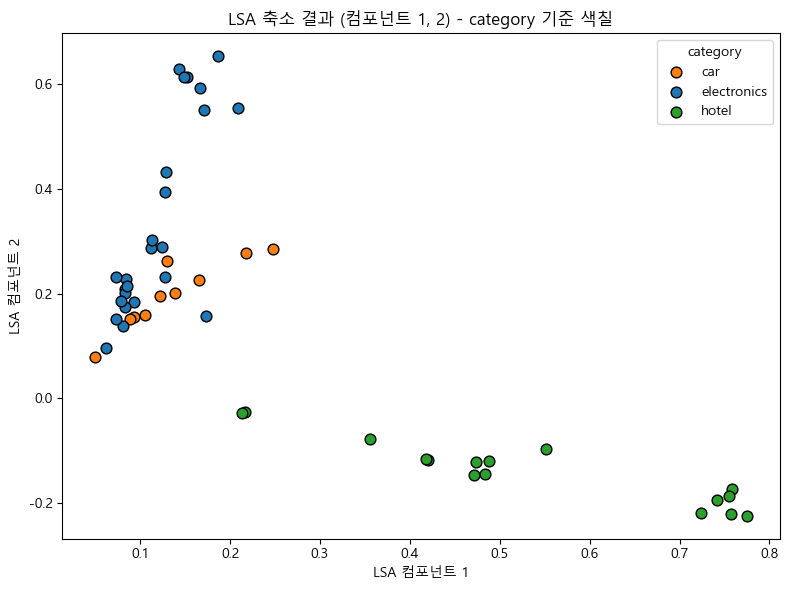

In [45]:
category_colors = {"electronics": "tab:blue", "car": "tab:orange", "hotel": "tab:green"}

fig, ax = plt.subplots(figsize=(8, 6))
for category, group_df in document_df.groupby("category"):
    idx = group_df.index
    ax.scatter(
        feature_vect_lsa[idx, 0],
        feature_vect_lsa[idx, 1],
        label=category,
        color=category_colors[category],
        s=60,
        edgecolor="black",
    )
ax.set_title("LSA 축소 결과 (컴포넌트 1, 2) - category 기준 색칠")
ax.set_xlabel("LSA 컴포넌트 1")
ax.set_ylabel("LSA 컴포넌트 2")
ax.legend(title="category")
plt.tight_layout()
plt.show()
